# EEGFormer vs Baselines: McNemar and Wilcoxon

This notebook performs:
- Subject-level comparison with majority-vote subject predictions using McNemar exact tests
- Fold-level paired comparison using Wilcoxon signed-rank tests

Reported metrics are: accuracy, recall, precision, specificity, and AUC.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon

# File paths
base = Path('../results')
raw_sources = {
    'EEGFormer': {'path': base / 'eegformer_5fold_run' / 'all_trial_probs.csv'},
    'CNN-LSTM-EEGNet': {'path': base / 'hypothesis tests' / 'cnn_lstm_eegnet_10seeds' / 'all_trial_probs.csv'},
    'EEGConformer': {'path': base / 'hypothesis tests' / 'eegconformer_10seeds', 'folder_mode': True},
    'TGARNet': {'path': base / 'hypothesis tests' / 'tgarnet_10seeds' / 'all_trial_probs.csv'},
    'ShallowConvNet': {'path': base / 'hypothesis tests' / 'shallowconvnet_10seeds' / 'all_trial_probs.csv'},
    'IMCBGT': {'path': base / 'hypothesis tests' / 'imcbgt_10seeds' / 'all_trial_probs.csv'},
    'MultiStream': {'path': base / 'hypothesis tests' / 'multistream_10seeds' / 'all_trial_probs.csv'},
    'EEGNet': {'path': base / 'hypothesis tests' / 'eegnet_10seeds' / 'all_trial_probs.csv'},
}

def load_trial_frame(source):
    path = Path(source['path'])
    if source.get('folder_mode'):
        csv_paths = sorted(path.glob('seed_*/trial_predictions.csv'))
        if not csv_paths:
            raise FileNotFoundError(f'No trial_predictions.csv files found under {path}')
        return pd.concat([pd.read_csv(csv_path) for csv_path in csv_paths], ignore_index=True)
    return pd.read_csv(path)

frames = {name: load_trial_frame(source) for name, source in raw_sources.items()}

# Keep one row per subject per fold (majority-vote predictions are already provided)
def build_subject_fold(df):
    required = {'seed', 'fold', 'subject', 'true_label', 'subject_majority_pred'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Missing required subject-level columns: {sorted(missing)}')

    if 'subject_mean_prob' in df.columns:
        cols = ['seed', 'fold', 'subject', 'true_label', 'subject_majority_pred', 'subject_mean_prob']
        out = df[cols].drop_duplicates().copy()
    else:
        cols = ['seed', 'fold', 'subject', 'true_label', 'subject_majority_pred']
        out = df[cols].drop_duplicates().copy()
        if 'prob_adhd' in df.columns:
            mean_prob = (
                df.groupby(['seed', 'fold', 'subject'], as_index=False)['prob_adhd']
                .mean()
                .rename(columns={'prob_adhd': 'subject_mean_prob'})
            )
            out = out.merge(mean_prob, on=['seed', 'fold', 'subject'], how='left')
        else:
            out['subject_mean_prob'] = np.nan

    out['seed'] = out['seed'].astype(int)
    out['fold'] = out['fold'].astype(int)
    out['true_label'] = out['true_label'].astype(int)
    out['subject_majority_pred'] = out['subject_majority_pred'].astype(int)
    out['subject_mean_prob'] = pd.to_numeric(out['subject_mean_prob'], errors='coerce')
    return out

subject_fold = {name: build_subject_fold(df) for name, df in frames.items()}

for name, df in subject_fold.items():
    print(f'{name}: rows={len(df)}, seeds={df.seed.nunique()}, folds={df.fold.nunique()}, subjects={df.subject.nunique()}')

EEGFormer: rows=120, seeds=1, folds=5, subjects=120
CNN-LSTM-EEGNet: rows=120, seeds=1, folds=5, subjects=120
EEGConformer: rows=1200, seeds=10, folds=5, subjects=120
TGARNet: rows=120, seeds=1, folds=5, subjects=120
ShallowConvNet: rows=120, seeds=1, folds=5, subjects=120
IMCBGT: rows=120, seeds=1, folds=5, subjects=120
MultiStream: rows=120, seeds=1, folds=5, subjects=120
EEGNet: rows=120, seeds=1, folds=5, subjects=120


In [7]:
# Subject-level overall metrics (majority voting)
def compute_metrics(y_true, y_pred, y_score=None):
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    specificity = (tn / (tn + fp)) if (tn + fp) > 0 else np.nan

    if y_score is None:
        y_score = y_pred.astype(float)

    if np.unique(y_true).size < 2:
        auc = np.nan
    else:
        auc = float(roc_auc_score(y_true, y_score))

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'auc': auc,
    }

# Per (seed, fold) subject-level metrics, then summarize as mean +- 1 std in %
subject_metric_rows = []
for model, df in subject_fold.items():
    for (seed, fold), g in df.groupby(['seed', 'fold'], sort=True):
        y_true = g['true_label'].astype(int).to_numpy()
        y_pred = g['subject_majority_pred'].astype(int).to_numpy()
        y_score = g['subject_mean_prob'].astype(float).to_numpy()
        m = compute_metrics(y_true, y_pred, y_score)
        subject_metric_rows.append({
            'model': model,
            'seed': int(seed),
            'fold': int(fold),
            **m,
        })

subject_metrics = pd.DataFrame(subject_metric_rows)
subject_overall_stats = (
    subject_metrics.groupby('model')[['accuracy', 'recall', 'precision', 'specificity', 'auc']]
    .agg(['mean', 'std'])
    .sort_values(('accuracy', 'mean'), ascending=False)
 )

def fmt_pct_pm1std(mean_val, std_val):
    std_val = 0.0 if pd.isna(std_val) else float(std_val)
    return f"{100.0 * float(mean_val):.2f}% +- {100.0 * std_val:.2f}%"

subject_overall = pd.DataFrame({
    'model': subject_overall_stats.index,
    'accuracy': [fmt_pct_pm1std(m, s) for m, s in zip(subject_overall_stats[('accuracy', 'mean')], subject_overall_stats[('accuracy', 'std')])],
    'recall': [fmt_pct_pm1std(m, s) for m, s in zip(subject_overall_stats[('recall', 'mean')], subject_overall_stats[('recall', 'std')])],
    'precision': [fmt_pct_pm1std(m, s) for m, s in zip(subject_overall_stats[('precision', 'mean')], subject_overall_stats[('precision', 'std')])],
    'specificity': [fmt_pct_pm1std(m, s) for m, s in zip(subject_overall_stats[('specificity', 'mean')], subject_overall_stats[('specificity', 'std')])],
    'auc': [fmt_pct_pm1std(m, s) for m, s in zip(subject_overall_stats[('auc', 'mean')], subject_overall_stats[('auc', 'std')])],
}).reset_index(drop=True)

print('Subject-level overall (majority vote, % mean +- 1 std):')
display(subject_overall)

# McNemar exact test on paired subject-level correctness
ref = subject_fold['EEGFormer'].copy()
ref['correct_ref'] = (ref['subject_majority_pred'].astype(int) == ref['true_label'].astype(int)).astype(int)

mcnemar_rows = []
for baseline in [m for m in subject_fold if m != 'EEGFormer']:
    cmp = subject_fold[baseline].copy()
    cmp['correct_cmp'] = (cmp['subject_majority_pred'].astype(int) == cmp['true_label'].astype(int)).astype(int)

    merged = ref[['seed', 'fold', 'subject', 'correct_ref']].merge(
        cmp[['seed', 'fold', 'subject', 'correct_cmp']],
        on=['seed', 'fold', 'subject'],
        how='inner',
        validate='one_to_one'
    )

    n10 = int(((merged.correct_ref == 1) & (merged.correct_cmp == 0)).sum())
    n01 = int(((merged.correct_ref == 0) & (merged.correct_cmp == 1)).sum())
    n11 = int(((merged.correct_ref == 1) & (merged.correct_cmp == 1)).sum())
    n00 = int(((merged.correct_ref == 0) & (merged.correct_cmp == 0)).sum())

    # McNemar table: off-diagonals are discordant counts (n10, n01)
    table = [[n11, n10], [n01, n00]]
    mc = mcnemar(table, exact=True, correction=False)

    if n10 == 0 and n01 == 0:
        ratio_n01_over_n10 = np.nan
        ratio_n10_over_n01 = np.nan
    elif n10 == 0:
        ratio_n01_over_n10 = np.inf
        ratio_n10_over_n01 = 0.0
    elif n01 == 0:
        ratio_n01_over_n10 = 0.0
        ratio_n10_over_n01 = np.inf
    else:
        ratio_n01_over_n10 = float(n01 / n10)
        ratio_n10_over_n01 = float(n10 / n01)

    mcnemar_rows.append({
        'comparison': f'EEGFormer vs {baseline}',
        'n_pairs': len(merged),
        'n11_both_correct': n11,
        'n10_ref_only_correct': n10,
        'n01_baseline_only_correct': n01,
        'n00_both_wrong': n00,
        'discordant_pairs': n10 + n01,
        'ratio_n01_over_n10': ratio_n01_over_n10,
        'ratio_n10_over_n01': ratio_n10_over_n01,
        'statistic': float(mc.statistic),
        'p_value': float(mc.pvalue),
    })

mcnemar_df = pd.DataFrame(mcnemar_rows).sort_values('p_value')
print('McNemar exact tests:')
display(
    mcnemar_df.style.format({
        'ratio_n01_over_n10': lambda v: 'NA' if pd.isna(v) else ('inf' if np.isinf(v) else f'{v:.3f}'),
        'ratio_n10_over_n01': lambda v: 'NA' if pd.isna(v) else ('inf' if np.isinf(v) else f'{v:.3f}'),
        'statistic': '{:.3f}',
        'p_value': '{:.6f}',
    })
)

Subject-level overall (majority vote, % mean +- 1 std):


,model,accuracy,recall,precision,specificity,auc
0,EEGFormer,87.50% +- 5.10%,96.00% +- 8.94%,82.83% +- 3.95%,79.61% +- 3.45%,89.86% +- 5.24%
1,ShallowConvNet,80.83% +- 3.73%,91.10% +- 9.00%,76.73% +- 8.17%,71.92% +- 7.98%,91.19% +- 3.41%
2,CNN-LSTM-EEGNet,80.00% +- 10.79%,93.33% +- 14.91%,75.96% +- 11.28%,68.84% +- 17.58%,92.08% +- 7.22%
3,EEGNet,79.17% +- 9.32%,88.36% +- 16.49%,76.16% +- 8.49%,71.92% +- 9.65%,87.18% +- 6.27%
4,EEGConformer,77.25% +- 8.17%,89.84% +- 12.79%,73.55% +- 8.49%,65.33% +- 13.87%,86.51% +- 7.19%
5,MultiStream,73.33% +- 5.59%,79.14% +- 13.43%,74.10% +- 12.77%,68.16% +- 19.11%,77.99% +- 8.74%
6,TGARNet,70.00% +- 14.25%,96.85% +- 4.40%,64.75% +- 12.16%,43.15% +- 25.64%,72.14% +- 14.23%
7,IMCBGT,69.17% +- 9.59%,77.40% +- 10.98%,68.38% +- 10.35%,61.04% +- 18.72%,78.46% +- 4.81%


McNemar exact tests:


,comparison,n_pairs,n11_both_correct,n10_ref_only_correct,n01_baseline_only_correct,n00_both_wrong,discordant_pairs,ratio_n01_over_n10,ratio_n10_over_n01,statistic,p_value
2,EEGFormer vs TGARNet,120,82,23,2,13,25,0.087,11.500,2.000,0.000019
4,EEGFormer vs IMCBGT,120,77,28,6,9,34,0.214,4.667,6.000,0.000195
1,EEGFormer vs EEGConformer,120,86,19,3,12,22,0.158,6.333,3.000,0.000855
5,EEGFormer vs MultiStream,120,81,24,7,8,31,0.292,3.429,7.000,0.003327
6,EEGFormer vs EEGNet,120,94,11,1,14,12,0.091,11.000,1.000,0.006348
0,EEGFormer vs CNN-LSTM-EEGNet,120,94,11,2,13,13,0.182,5.500,2.000,0.022461
3,EEGFormer vs ShallowConvNet,120,94,11,3,12,14,0.273,3.667,3.000,0.057373


In [8]:
from scipy.stats import ttest_ind, ttest_rel

# Build EEGFormer subject-level correctness once
eegformer_subj = (
    subject_fold['EEGFormer'][['seed', 'fold', 'subject', 'true_label', 'subject_majority_pred']]
    .drop_duplicates()
    .assign(EEGFormer=lambda d: (d['subject_majority_pred'].astype(int) == d['true_label'].astype(int)).astype(int))
    [['seed', 'fold', 'subject', 'EEGFormer']]
)

# Compare EEGFormer vs each baseline using aligned subject pairs
ttest_rows = []
for baseline in [m for m in subject_fold.keys() if m != 'EEGFormer']:
    baseline_subj = (
        subject_fold[baseline][['seed', 'fold', 'subject', 'true_label', 'subject_majority_pred']]
        .drop_duplicates()
        .assign(Baseline=lambda d: (d['subject_majority_pred'].astype(int) == d['true_label'].astype(int)).astype(int))
        [['seed', 'fold', 'subject', 'Baseline']]
    )

    data_subj = eegformer_subj.merge(
        baseline_subj,
        on=['seed', 'fold', 'subject'],
        how='inner',
        validate='one_to_one',
    )

    t_stat_ind, p_ttest_ind = ttest_ind(
        data_subj['EEGFormer'],
        data_subj['Baseline'],
        alternative='greater',
    )

    t_stat_rel, p_ttest_rel = ttest_rel(
        data_subj['EEGFormer'],
        data_subj['Baseline'],
        alternative='greater',
    )

    ttest_rows.append({
        'comparison': f'EEGFormer vs {baseline}',
        'n_pairs': len(data_subj),
        'mean_EEGFormer_correct': data_subj['EEGFormer'].mean(),
        'mean_baseline_correct': data_subj['Baseline'].mean(),
        'mean_diff_correct': (data_subj['EEGFormer'] - data_subj['Baseline']).mean(),
        'ind_t_stat': float(t_stat_ind),
        'ind_p_value': float(p_ttest_ind),
        'paired_t_stat': float(t_stat_rel),
        'paired_p_value': float(p_ttest_rel),
    })

ttest_df = pd.DataFrame(ttest_rows).sort_values('paired_p_value').reset_index(drop=True)
print('Subject-level t-test comparisons (EEGFormer vs each baseline):')
display(
    ttest_df.style.format({
        'mean_EEGFormer_correct': '{:.4f}',
        'mean_baseline_correct': '{:.4f}',
        'mean_diff_correct': '{:.4f}',
        'ind_t_stat': '{:.4f}',
        'ind_p_value': '{:.6f}',
        'paired_t_stat': '{:.4f}',
        'paired_p_value': '{:.6f}',
    })
)

Subject-level t-test comparisons (EEGFormer vs each baseline):


,comparison,n_pairs,mean_EEGFormer_correct,mean_baseline_correct,mean_diff_correct,ind_t_stat,ind_p_value,paired_t_stat,paired_p_value
0,EEGFormer vs TGARNet,120,0.8750,0.7000,0.1750,3.3780,0.000426,4.5285,0.000007
1,EEGFormer vs IMCBGT,120,0.8750,0.6917,0.1833,3.5209,0.000258,4.0021,0.000055
2,EEGFormer vs EEGConformer,120,0.8750,0.7417,0.1333,2.6512,0.004279,3.5747,0.000254
3,EEGFormer vs MultiStream,120,0.8750,0.7333,0.1417,2.7986,0.002777,3.1660,0.000982
4,EEGFormer vs EEGNet,120,0.8750,0.7917,0.0833,1.7357,0.041955,2.9800,0.001748
5,EEGFormer vs CNN-LSTM-EEGNet,120,0.8750,0.8000,0.0750,1.5764,0.058135,2.5529,0.005974
6,EEGFormer vs ShallowConvNet,120,0.8750,0.8083,0.0667,1.4146,0.079249,2.1709,0.015962


In [9]:
# Seed/fold summaries from hypothesis tests folders (all models, including EEGFormer)
hyp_base = Path('../results/hypothesis tests')
model_specs = {
    'EEGFormer': {'folder': 'eegformer_10seeds'},
    'CNN-LSTM-EEGNet': {'folder': 'cnn_lstm_eegnet_10seeds'},
    'EEGConformer': {'trial_dir': hyp_base / 'eegconformer_10seeds', 'folder_mode': True},
    'TGARNet': {'folder': 'tgarnet_10seeds'},
    'ShallowConvNet': {'folder': 'shallowconvnet_10seeds'},
    'IMCBGT': {'folder': 'imcbgt_10seeds'},
    'MultiStream': {'folder': 'multistream_10seeds'},
    'EEGNet': {'folder': 'eegnet_10seeds'},
}

def fold_metrics_from_trial_predictions(trials):
    required = {'seed', 'fold', 'subject', 'true_label', 'subject_majority_pred'}
    missing = required - set(trials.columns)
    if missing:
        raise ValueError(f'trial predictions missing columns: {sorted(missing)}')

    if 'subject_mean_prob' in trials.columns:
        subject_level = trials[['seed', 'fold', 'subject', 'true_label', 'subject_majority_pred', 'subject_mean_prob']].drop_duplicates().copy()
    else:
        subject_level = trials[['seed', 'fold', 'subject', 'true_label', 'subject_majority_pred']].drop_duplicates().copy()
        if 'prob_adhd' in trials.columns:
            mean_prob = (
                trials.groupby(['seed', 'fold', 'subject'], as_index=False)['prob_adhd']
                .mean()
                .rename(columns={'prob_adhd': 'subject_mean_prob'})
            )
            subject_level = subject_level.merge(mean_prob, on=['seed', 'fold', 'subject'], how='left')
        else:
            subject_level['subject_mean_prob'] = np.nan

    subject_level['seed'] = subject_level['seed'].astype(int)
    subject_level['fold'] = subject_level['fold'].astype(int)
    subject_level['subject_mean_prob'] = pd.to_numeric(subject_level['subject_mean_prob'], errors='coerce')

    rows = []
    for (seed, fold), group in subject_level.groupby(['seed', 'fold'], sort=True):
        y_true = group['true_label'].astype(int).to_numpy()
        y_pred = group['subject_majority_pred'].astype(int).to_numpy()
        y_score = group['subject_mean_prob'].astype(float).to_numpy()
        fold_m = compute_metrics(y_true, y_pred, y_score)
        rows.append({
            'seed': int(seed),
            'fold': int(fold),
            **fold_m,
        })
    return pd.DataFrame(rows)

def load_fold_metrics(model, spec):
    if spec.get('folder_mode'):
        return fold_metrics_from_trial_predictions(load_trial_frame({'path': spec['trial_dir'], 'folder_mode': True}))

    folder = spec['folder']
    path = hyp_base / folder / 'all_fold_results.csv'
    df = pd.read_csv(path)
    required = {'seed', 'fold', 'accuracy'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{model} all_fold_results.csv missing columns: {sorted(missing)}")

    use = df[['seed', 'fold', 'accuracy']].copy()
    use['seed'] = use['seed'].astype(int)
    use['fold'] = use['fold'].astype(int)
    use['accuracy'] = use['accuracy'].astype(float)
    use['recall'] = pd.to_numeric(df['recall'], errors='coerce') if 'recall' in df.columns else np.nan
    use['precision'] = pd.to_numeric(df['precision'], errors='coerce') if 'precision' in df.columns else np.nan
    use['specificity'] = pd.to_numeric(df['specificity'], errors='coerce') if 'specificity' in df.columns else np.nan
    use['auc'] = pd.to_numeric(df['auc'], errors='coerce') if 'auc' in df.columns else np.nan
    return use

def load_seed_summary(model, spec, fold_df):
    if spec.get('folder_mode'):
        return (
            fold_df.groupby('seed', sort=True)['accuracy']
            .agg(mean_accuracy='mean', std_accuracy=lambda s: float(s.std(ddof=1)))
            .reset_index()
        )

    path = hyp_base / spec['folder'] / 'all_seed_summaries.csv'
    return pd.read_csv(path)

fold_metric_frames = {model: load_fold_metrics(model, spec) for model, spec in model_specs.items()}
seed_summaries = {
    model: load_seed_summary(model, spec, fold_metric_frames[model])
    for model, spec in model_specs.items()
}

seed_summary_rows = []
for model, df in seed_summaries.items():
    required = {'seed', 'mean_accuracy', 'std_accuracy'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{model} all_seed_summaries.csv missing columns: {sorted(missing)}")

    acc_seed_means = df['mean_accuracy'].astype(float)
    seed_summary_rows.append({
        'model': model,
        'n_seeds': int(df['seed'].nunique()),
        'mean_accuracy_over_seeds': float(acc_seed_means.mean()),
        'std_accuracy_over_seeds': float(acc_seed_means.std(ddof=1)),
        'mean_within_seed_std_accuracy': float(df['std_accuracy'].astype(float).mean()),
    })

seed_summary_df = pd.DataFrame(seed_summary_rows).sort_values('mean_accuracy_over_seeds', ascending=False)
print('Seed-level summary from all_seed_summaries.csv (accuracy only):')
display(seed_summary_df.round(4))

# Build fold-level metric table from all_fold_results.csv or trial_predictions.csv (5 folds x 10 seeds = 50 points/model)
fold_metrics = pd.concat(
    [df.assign(model=model) for model, df in fold_metric_frames.items()],
    ignore_index=True,
)

# Fill missing fold metrics (e.g., specificity) from subject-level trial predictions
raw_metric_frames = {
    model: fold_metrics_from_trial_predictions(df).assign(model=model)
    for model, df in frames.items()
}
raw_fold_metrics = pd.concat(raw_metric_frames.values(), ignore_index=True)

fold_metrics = fold_metrics.merge(
    raw_fold_metrics[['model', 'seed', 'fold', 'recall', 'precision', 'specificity', 'auc']],
    on=['model', 'seed', 'fold'],
    how='left',
    suffixes=('', '_raw'),
)
for metric in ['recall', 'precision', 'specificity', 'auc']:
    fold_metrics[metric] = fold_metrics[metric].combine_first(fold_metrics[f'{metric}_raw'])
    fold_metrics = fold_metrics.drop(columns=[f'{metric}_raw'])

# Wilcoxon-side metric summary in % mean +- 1 std
wilcoxon_metric_rows = []
for model, g in fold_metrics.groupby('model', sort=True):
    row = {'model': model}
    for metric in ['accuracy', 'recall', 'precision', 'specificity', 'auc']:
        vals = g[metric].dropna().astype(float)
        if len(vals) == 0:
            row[metric] = 'NA'
        else:
            row[metric] = f"{100.0 * vals.mean():.2f}% +- {100.0 * vals.std(ddof=1):.2f}%"
    row['_acc_sort'] = g['accuracy'].mean()
    wilcoxon_metric_rows.append(row)

wilcoxon_metric_summary = (
    pd.DataFrame(wilcoxon_metric_rows)
    .sort_values('_acc_sort', ascending=False)
    .drop(columns=['_acc_sort'])
    .reset_index(drop=True)
 )
print('Wilcoxon-side overall metrics (5 folds x 10 seeds, % mean +- 1 std):')
display(wilcoxon_metric_summary)
print('Note: missing fold metrics are backfilled from subject-level trial predictions when available.')

fold_counts = (
    fold_metrics.groupby('model')
    .agg(n_pairs=('accuracy', 'size'), n_seeds=('seed', 'nunique'), n_folds=('fold', 'nunique'))
    .sort_index()
    .reset_index()
 )
print('Fold-count check (expected n_pairs=50, n_seeds=10, n_folds=5):')
display(fold_counts)

# Average rank over paired seed-fold accuracies (lower rank is better)
rank_table = fold_metrics.pivot_table(index=['seed', 'fold'], columns='model', values='accuracy', aggfunc='first')
rank_table = rank_table.dropna(axis=0, how='any')
avg_ranks = rank_table.rank(axis=1, ascending=False, method='average').mean(axis=0)

# Wilcoxon signed-rank tests on 50 paired fold accuracies (EEGFormer vs each baseline)
ref = fold_metrics[fold_metrics.model == 'EEGFormer'][['seed', 'fold', 'accuracy']].rename(columns={'accuracy': 'acc_ref'})

wilcoxon_rows = []
for baseline in [m for m in model_specs if m != 'EEGFormer']:
    cmp = fold_metrics[fold_metrics.model == baseline][['seed', 'fold', 'accuracy']].rename(columns={'accuracy': 'acc_cmp'})
    merged = ref.merge(cmp, on=['seed', 'fold'], how='inner', validate='one_to_one')

    diff = merged['acc_ref'] - merged['acc_cmp']
    if np.allclose(diff.to_numpy(), 0.0):
        stat, pval = 0.0, 1.0
    else:
        w = wilcoxon(
            merged['acc_ref'],
            merged['acc_cmp'],
            alternative='greater',
            zero_method='wilcox',
            mode='auto',
        )
        stat, pval = float(w.statistic), float(w.pvalue)

    wilcoxon_rows.append({
        'comparison': f'EEGFormer vs {baseline}',
        'n_pairs': int(len(merged)),
        'avg_rank_EEGFormer': float(avg_ranks['EEGFormer']),
        'avg_rank_baseline': float(avg_ranks[baseline]),
        'median_diff_acc': float(np.median(diff)),
        'mean_diff_acc': float(np.mean(diff)),
        'wilcoxon_W': stat,
        'p_value_one_sided_greater': pval,
    })

wilcoxon_df = pd.DataFrame(wilcoxon_rows).sort_values('p_value_one_sided_greater').reset_index(drop=True)
print('Wilcoxon signed-rank tests (5 folds x 10 seeds paired accuracies, one-sided greater):')
display(wilcoxon_df.round(6))

Seed-level summary from all_seed_summaries.csv (accuracy only):


,model,n_seeds,mean_accuracy_over_seeds,std_accuracy_over_seeds,mean_within_seed_std_accuracy
1,CNN-LSTM-EEGNet,10,0.8425,0.0298,0.0696
0,EEGFormer,10,0.8417,0.0176,0.0562
7,EEGNet,10,0.8067,0.0135,0.0809
4,ShallowConvNet,10,0.7867,0.0324,0.0900
2,EEGConformer,10,0.7725,0.0226,0.0833
3,TGARNet,10,0.7475,0.0291,0.0705
5,IMCBGT,10,0.7058,0.0147,0.1036
6,MultiStream,10,0.6925,0.0290,0.0783


Wilcoxon-side overall metrics (5 folds x 10 seeds, % mean +- 1 std):


,model,accuracy,recall,precision,specificity,auc
0,CNN-LSTM-EEGNet,84.25% +- 7.35%,93.76% +- 8.92%,79.88% +- 7.70%,68.84% +- 17.58%,91.98% +- 5.56%
1,EEGFormer,84.17% +- 5.39%,96.00% +- 8.94%,82.83% +- 3.95%,79.61% +- 3.45%,90.54% +- 5.24%
2,EEGNet,80.67% +- 7.47%,88.36% +- 16.49%,76.16% +- 8.49%,71.92% +- 9.65%,89.25% +- 4.94%
3,ShallowConvNet,78.67% +- 9.44%,91.10% +- 9.00%,76.73% +- 8.17%,71.92% +- 7.98%,90.25% +- 3.62%
4,EEGConformer,77.25% +- 8.17%,89.84% +- 12.79%,73.55% +- 8.49%,65.33% +- 13.87%,86.51% +- 7.19%
5,TGARNet,74.75% +- 8.27%,96.85% +- 4.40%,64.75% +- 12.16%,43.15% +- 25.64%,78.57% +- 10.00%
6,IMCBGT,70.58% +- 9.61%,79.99% +- 12.04%,68.92% +- 9.56%,61.04% +- 18.72%,78.90% +- 4.98%
7,MultiStream,69.25% +- 7.94%,79.14% +- 13.43%,74.10% +- 12.77%,68.16% +- 19.11%,76.29% +- 7.13%


Note: missing fold metrics are backfilled from subject-level trial predictions when available.
Fold-count check (expected n_pairs=50, n_seeds=10, n_folds=5):


,model,n_pairs,n_seeds,n_folds
0,CNN-LSTM-EEGNet,50,10,5
1,EEGConformer,50,10,5
2,EEGFormer,50,10,5
3,EEGNet,50,10,5
4,IMCBGT,50,10,5
5,MultiStream,50,10,5
6,ShallowConvNet,50,10,5
7,TGARNet,50,10,5


Wilcoxon signed-rank tests (5 folds x 10 seeds paired accuracies, one-sided greater):


,comparison,n_pairs,avg_rank_EEGFormer,avg_rank_baseline,median_diff_acc,mean_diff_acc,wilcoxon_W,p_value_one_sided_greater
0,EEGFormer vs MultiStream,50,2.61,6.60,0.166667,0.149167,1081.0,0.000000
1,EEGFormer vs IMCBGT,50,2.61,6.10,0.125000,0.135833,1064.0,0.000000
2,EEGFormer vs TGARNet,50,2.61,5.29,0.083333,0.094167,984.0,0.000000
3,EEGFormer vs EEGConformer,50,2.61,4.78,0.062500,0.069167,862.0,0.000000
4,EEGFormer vs EEGNet,50,2.61,3.85,0.041667,0.035000,706.5,0.000028
5,EEGFormer vs ShallowConvNet,50,2.61,4.12,0.041667,0.055000,632.0,0.000350
6,EEGFormer vs CNN-LSTM-EEGNet,50,2.61,2.65,0.000000,-0.000833,346.0,0.533371


In [10]:

# ============================================================
# Complete two-section LaTeX table
#   Top   : Varying seed – Wilcoxon signed-rank significance
#            on ALL five metrics (50 paired folds per model)
#   Bottom: Best seed     – McNemar OR significance
#            (1 seed × 5 folds, from subject_fold / mcnemar_df)
#
# Depends on: subject_overall_stats, mcnemar_df  (cell above)
# ============================================================
import json
from IPython.display import display as ipy_display, Markdown
from sklearn.metrics import roc_auc_score

HYP = Path('../results/hypothesis tests')
COMMON_SEEDS = {7, 42, 99, 123, 314, 456, 789, 2024, 2718, 5000}

# Display order must match LaTeX column order
DISPLAY_MODELS  = ['EEGNet', 'ShallowConvNet', 'CNN-LSTM', 'MultiStream',
                   'EEGConformer', 'IMCBGT', 'TGARNet', 'EEGFormer']
DISPLAY_HEADERS = ['EEGNet', 'ShallowConvNet', 'CNN-LSTM', 'Multi-Stream',
                   'EEGConformer', 'IM-CBGT', 'T-GARNet', 'EEG-TACT']

# Mapping new display names → old names used in subject_fold / mcnemar_df
OLD_NAME = {
    'EEGNet': 'EEGNet',         'ShallowConvNet': 'ShallowConvNet',
    'CNN-LSTM': 'CNN-LSTM-EEGNet', 'MultiStream': 'MultiStream',
    'EEGConformer': 'EEGConformer', 'IMCBGT': 'IMCBGT',
    'TGARNet': 'TGARNet',       'EEGFormer': 'EEGFormer',
}

REF     = 'EEGFormer'
METRICS = ['accuracy', 'recall', 'precision', 'specificity', 'auc']
METRIC_LABELS = {
    'accuracy':    r'Accuracy (\%)',
    'recall':      r'Recall (\%)',
    'precision':   r'Precision (\%)',
    'specificity': r'Specificity (\%)',
    'auc':         r'AUC (\%)',
}

# EEGConformer: fold-level std (no single "best seed" reference, all 50 folds treated equally)
# CNN-LSTM, IMCBGT: fold-level std (direct recall/precision from CSV)
# All others: seed-level std (std of 10 per-seed means → between-seed variability only)
FOLD_LEVEL = {'CNN-LSTM', 'IMCBGT', 'EEGConformer'}

# Average rank uses only the 7 original models (EEGConformer added later, excluded for consistency
# with scripts/friedman_test.py and scripts/wilcoxon_test.py which also use 7 models)
RANK_MODELS = [m for m in DISPLAY_MODELS if m != 'EEGConformer']

# ── Step 1: infer fold prevalence from CNN-LSTM all_fold_results ──────────
_cnn = pd.read_csv(HYP / 'cnn_lstm_eegnet_10seeds' / 'all_fold_results.csv')
fold_prev = {}
for fold_id, g in _cnn.groupby('fold'):
    a  = g['accuracy'].astype(float).to_numpy()
    b  = g['balanced_acc'].astype(float).to_numpy()
    r  = g['recall'].astype(float).to_numpy()
    sp = 2.0 * b - r
    dn = r - sp
    ok = np.abs(dn) > 1e-12
    fold_prev[int(fold_id)] = float(np.nanmean((a[ok] - sp[ok]) / dn[ok]))

print('Inferred fold prevalence:',
      {k: round(v, 4) for k, v in sorted(fold_prev.items())})

# ── Step 2: reconstruct recall / precision / specificity ──────────────────
def reconstruct(acc, bal, f1_val, fold_id):
    p  = fold_prev[int(fold_id)]
    dn = 2.0 * p - 1.0
    if abs(dn) < 1e-12:
        return np.nan, np.nan, np.nan
    rec = float(np.clip((acc - 2.0 * (1.0 - p) * bal) / dn, 0.0, 1.0))
    dn2 = 2.0 * rec - f1_val
    pre = float(np.clip((f1_val * rec) / dn2, 0.0, 1.0)) if abs(dn2) > 1e-12 else np.nan
    spc = float(np.clip(2.0 * bal - rec, 0.0, 1.0))
    return rec, pre, spc

# ── Step 3: load / reconstruct per-(seed, fold) metrics ───────────────────
MODEL_SOURCES = {
    'EEGNet':        ('eegnet_10seeds',          False),
    'ShallowConvNet':('shallowconvnet_10seeds',   False),
    'CNN-LSTM':      ('cnn_lstm_eegnet_10seeds',  True),
    'MultiStream':   ('multistream_10seeds',      False),
    'IMCBGT':        ('imcbgt_10seeds',           True),
    'TGARNet':       ('tgarnet_10seeds',          False),
    'EEGFormer':     ('eegformer_10seeds',        False),
}

all_fold = {}
for mname, (folder, has_direct_rp) in MODEL_SOURCES.items():
    df = pd.read_csv(HYP / folder / 'all_fold_results.csv')
    df = df[df['seed'].astype(int).isin(COMMON_SEEDS)].copy()
    df['seed'] = df['seed'].astype(int)
    df['fold'] = df['fold'].astype(int)
    rows = []
    for _, row in df.iterrows():
        a   = float(row['accuracy'])
        b   = float(row['balanced_acc'])
        f1v = float(row['f1'])
        au  = float(row['auc'])
        if has_direct_rp:
            rec = float(row['recall'])
            pre = float(row['precision'])
            spc = float(np.clip(2.0 * b - rec, 0.0, 1.0))
        else:
            rec, pre, spc = reconstruct(a, b, f1v, int(row['fold']))
        rows.append({'seed': int(row['seed']), 'fold': int(row['fold']),
                     'accuracy': a, 'recall': rec, 'precision': pre,
                     'specificity': spc, 'auc': au})
    all_fold[mname] = pd.DataFrame(rows)

# EEGConformer: metrics from fold_results.json + AUC from trial_predictions
conf_base = HYP / 'eegconformer_10seeds'

auc_conf = {}
for sd in sorted(conf_base.glob('seed_*')):
    tc = sd / 'trial_predictions.csv'
    if not tc.exists():
        continue
    t  = pd.read_csv(tc)
    sv = int(t['seed'].iloc[0])
    if sv not in COMMON_SEEDS:
        continue
    subj = t[['fold', 'subject', 'true_label', 'subject_mean_prob']].drop_duplicates()
    for fv, fg in subj.groupby('fold'):
        yt = fg['true_label'].astype(int).to_numpy()
        yp = fg['subject_mean_prob'].astype(float).to_numpy()
        auc_conf[(sv, int(fv))] = (
            float(roc_auc_score(yt, yp)) if np.unique(yt).size >= 2 else np.nan
        )

conf_rows = []
for sd in sorted(conf_base.glob('seed_*')):
    jp = sd / 'fold_results.json'
    if not jp.exists():
        continue
    with open(jp) as fh:
        entries = json.load(fh)
    for e in entries:
        sv = int(e['seed'])
        if sv not in COMMON_SEEDS:
            continue
        fv  = int(e['fold'])
        a   = float(e['test_subject_acc'])
        b   = float(e['test_subject_bacc'])
        f1v = float(e['test_subject_f1'])
        rec, pre, spc = reconstruct(a, b, f1v, fv)
        conf_rows.append({'seed': sv, 'fold': fv, 'accuracy': a,
                          'recall': rec, 'precision': pre,
                          'specificity': spc,
                          'auc': auc_conf.get((sv, fv), np.nan)})
all_fold['EEGConformer'] = pd.DataFrame(conf_rows)

print('\nData check (expect 50 rows, 10 seeds, 5 folds each):')
for m in DISPLAY_MODELS:
    df = all_fold[m]
    print(f'  {m}: {len(df)} rows, {df.seed.nunique()} seeds, {df.fold.nunique()} folds')

# ── Step 4: Wilcoxon signed-rank (one-sided EEGFormer > baseline) ─────────
ref_df = all_fold[REF][['seed', 'fold'] + METRICS].rename(
    columns={m: f'{m}_ref' for m in METRICS}
)

wilcoxon_sig  = {}   # (metric, baseline_new_name) -> bool
wilcoxon_pval = {}

for baseline in [m for m in DISPLAY_MODELS if m != REF]:
    cmp_df = all_fold[baseline][['seed', 'fold'] + METRICS].rename(
        columns={m: f'{m}_cmp' for m in METRICS}
    )
    merged = ref_df.merge(cmp_df, on=['seed', 'fold'], how='inner')
    for metric in METRICS:
        pair = merged[[f'{metric}_ref', f'{metric}_cmp']].dropna()
        if len(pair) < 2:
            wilcoxon_sig[(metric, baseline)], wilcoxon_pval[(metric, baseline)] = False, np.nan
            continue
        diff = pair[f'{metric}_ref'].to_numpy() - pair[f'{metric}_cmp'].to_numpy()
        if np.allclose(diff, 0.0):
            wilcoxon_sig[(metric, baseline)], wilcoxon_pval[(metric, baseline)] = False, 1.0
        else:
            w = wilcoxon(pair[f'{metric}_ref'], pair[f'{metric}_cmp'],
                         alternative='greater', zero_method='wilcox', mode='auto')
            p = float(w.pvalue)
            wilcoxon_sig[(metric, baseline)] = p < 0.05
            wilcoxon_pval[(metric, baseline)] = p

baselines = [m for m in DISPLAY_MODELS if m != REF]
pval_df = pd.DataFrame(
    {b: {m: round(wilcoxon_pval.get((m, b), np.nan), 4) for m in METRICS}
     for b in baselines}
).T
pval_df.index.name = 'baseline'
print('\nWilcoxon p-values (one-sided EEGFormer > baseline, p<0.05 → shaded cell):')
ipy_display(pval_df)

# ── Step 5: display statistics (mean ± std %) ─────────────────────────────
disp_stats = {}
for mname in DISPLAY_MODELS:
    df = all_fold[mname]
    for metric in METRICS:
        vals = df[metric].dropna().astype(float)
        if mname in FOLD_LEVEL:
            mean_pct = 100.0 * vals.mean()
            std_pct  = 100.0 * vals.std(ddof=1)
        else:
            seed_means = df.groupby('seed')[metric].mean().dropna()
            mean_pct = 100.0 * seed_means.mean()
            std_pct  = 100.0 * seed_means.std(ddof=1)
        disp_stats[(mname, metric)] = (float(mean_pct), float(std_pct))

summary_rows = []
for mname in DISPLAY_MODELS:
    row = {'model': mname}
    for metric in METRICS:
        mu, sd = disp_stats[(mname, metric)]
        row[metric] = f'{mu:.1f} ± {sd:.1f}' if not np.isnan(mu) else 'NaN'
    summary_rows.append(row)
print('\nVarying-seed display statistics (mean ± std %):')
ipy_display(pd.DataFrame(summary_rows).set_index('model'))

# ── Step 6: average accuracy rank (7 models, EEGConformer excluded) ───────
rank_df = pd.DataFrame(
    {m: all_fold[m].set_index(['seed', 'fold'])['accuracy'] for m in RANK_MODELS}
).dropna(axis=0, how='any')
avg_rank_7 = rank_df.rank(axis=1, ascending=False, method='average').mean(axis=0)
print(f'\nAverage accuracy rank over {len(RANK_MODELS)} models '
      f'(EEGConformer excluded – consistent with friedman/wilcoxon scripts):')
ipy_display(avg_rank_7.sort_values().to_frame('avg_rank').round(2))

# ── Step 7: best-seed stats from subject_overall_stats (cell above) ───────
best_stats = {}
for new_name in DISPLAY_MODELS:
    old_name = OLD_NAME[new_name]
    row = subject_overall_stats.loc[old_name]
    best_stats[new_name] = {}
    for metric in METRICS:
        mu = float(row[(metric, 'mean')])
        sd = float(row[(metric, 'std')]) if not pd.isna(row[(metric, 'std')]) else 0.0
        best_stats[new_name][metric] = (100.0 * mu, 100.0 * sd)

print('\nBest-seed statistics (1 seed × 5 folds, from subject_overall_stats):')
best_rows = [{'model': m, **{mt: f'{best_stats[m][mt][0]:.1f} ± {best_stats[m][mt][1]:.1f}'
                             for mt in METRICS}}
             for m in DISPLAY_MODELS]
ipy_display(pd.DataFrame(best_rows).set_index('model'))

# ── Step 8: McNemar OR (n10/n01) and significance from mcnemar_df ─────────
mc_sig  = {}
mc_text = {}
for new_name in [m for m in DISPLAY_MODELS if m != REF]:
    old_name = OLD_NAME[new_name]
    row = mcnemar_df[mcnemar_df['comparison'] == f'EEGFormer vs {old_name}']
    if len(row) == 0:
        mc_sig[new_name], mc_text[new_name] = False, '--'
        continue
    row = row.iloc[0]
    n10 = int(row['n10_ref_only_correct'])   # EEGFormer correct, baseline wrong
    n01 = int(row['n01_baseline_only_correct'])  # baseline correct, EEGFormer wrong
    p   = float(row['p_value'])
    mc_sig[new_name]  = p < 0.05
    mc_text[new_name] = f'{n10}/{n01}'
mc_sig[REF]  = False
mc_text[REF] = '--'

print('\nMcNemar OR (n_EEGFormer-wins / n_baseline-wins), significant when p < 0.05:')
for m in DISPLAY_MODELS:
    if m == REF:
        print(f'  {m}: reference')
    else:
        old = OLD_NAME[m]
        p_row = mcnemar_df[mcnemar_df.comparison == f'EEGFormer vs {old}']
        p_val = float(p_row.p_value.values[0]) if len(p_row) else np.nan
        print(f'  {m}: {mc_text[m]}, sig={mc_sig[m]}, p={p_val:.6f}')

# ── Step 9: LaTeX cell formatters ─────────────────────────────────────────
SEP = '\n& '
END = r'\\'

def _fmt(mu, sd, bold, shade):
    if np.isnan(mu):
        return ''
    inner = f'{mu:.1f} \\pm {sd:.1f}' if not np.isnan(sd) else f'{mu:.1f}'
    if bold:
        inner = f'\\mathbf{{{inner}}}'
    body = f'${{{inner}}}$'
    if shade:
        body = f'\\cellcolor{{lightgray}}{body}'
    return body

def _best(stats_fn, metric):
    vals = [round(stats_fn(m, metric), 1) for m in DISPLAY_MODELS
            if not np.isnan(stats_fn(m, metric))]
    return max(vals) if vals else np.nan

def fmt_var(mname, metric):
    mu, sd = disp_stats[(mname, metric)]
    best = _best(lambda m, mt: disp_stats[(m, mt)][0], metric)
    shade = (mname != REF) and wilcoxon_sig.get((metric, mname), False)
    return _fmt(mu, sd, round(mu, 1) == best, shade)

def fmt_best(mname, metric):
    mu, sd = best_stats[mname][metric]
    best = _best(lambda m, mt: best_stats[m][mt][0], metric)
    return _fmt(mu, sd, round(mu, 1) == best, False)

def fmt_or(mname):
    if mname == REF:
        return '--'
    text = mc_text.get(mname, '--')
    body = f'${{{text}}}$' if text != '--' else '--'
    if mc_sig.get(mname, False):
        body = f'\\cellcolor{{lightgray}}{body}'
    return body

# ── Step 10: assemble complete LaTeX table ────────────────────────────────
YEAR   = {'EEGNet': '2017', 'ShallowConvNet': '2017', 'CNN-LSTM': '2022',
          'MultiStream': '2023', 'EEGConformer': '2023', 'IMCBGT': '2024',
          'TGARNet': '2025', 'EEGFormer': '2026'}
PARAMS = {'EEGNet': '1{,}746', 'ShallowConvNet': '36{,}522', 'CNN-LSTM': '9{,}052',
          'MultiStream': '574{,}082', 'EEGConformer': '789{,}506',
          'IMCBGT': '1{,}195{,}266', 'TGARNet': '9{,}071', 'EEGFormer': '7{,}322'}

lines = [
    r'\begin{tabular}{lcccccccc}',
    r'\toprule',
    r'\textbf{Model}' + SEP + SEP.join(f'\\textbf{{{h}}}' for h in DISPLAY_HEADERS) + END,
    r'\midrule',
    'Year'       + SEP + SEP.join(YEAR[m]   for m in DISPLAY_MODELS) + END,
    'Parameters' + SEP + SEP.join(PARAMS[m] for m in DISPLAY_MODELS) + END,
    r'\midrule',
    r'\multicolumn{9}{c}{\textbf{Varying seed (average over 50 folds)}} \\',
    r'\midrule',
]

for metric in METRICS:
    lines.append(METRIC_LABELS[metric] + SEP
                 + SEP.join(fmt_var(m, metric) for m in DISPLAY_MODELS) + END)

rank_vals = [avg_rank_7.get(m, np.nan) for m in DISPLAY_MODELS]
best_rank = min(v for v in rank_vals if not np.isnan(v))
rank_cells = []
for m, rv in zip(DISPLAY_MODELS, rank_vals):
    if m == 'EEGConformer':
        rank_cells.append('')          # excluded from rank computation
    elif np.isnan(rv):
        rank_cells.append('')
    elif abs(rv - best_rank) < 1e-9:
        rank_cells.append(f'$\\mathbf{{{rv:.2f}}}$')
    else:
        rank_cells.append(f'${rv:.2f}$')
lines.append('Average Rank' + SEP + SEP.join(rank_cells) + END)

lines += [
    r'\midrule',
    r'\multicolumn{9}{c}{\textbf{Best seed (average over 5 folds)}} \\',
    r'\midrule',
]

for metric in METRICS:
    lines.append(METRIC_LABELS[metric] + SEP
                 + SEP.join(fmt_best(m, metric) for m in DISPLAY_MODELS) + END)

lines.append('Odds ratio' + SEP
             + SEP.join(fmt_or(m) for m in DISPLAY_MODELS) + END)
lines += [r'\bottomrule', r'\end{tabular}']

latex_out = '\n'.join(lines)

out_tex = Path('../results/evaluation/complete_model_comparison_table.tex')
out_tex.parent.mkdir(parents=True, exist_ok=True)
out_tex.write_text(latex_out, encoding='utf-8')
print(f'\nSaved LaTeX to: {out_tex.resolve()}')
ipy_display(Markdown(f'### Complete model comparison table\n\n```latex\n{latex_out}\n```'))


Inferred fold prevalence: {0: 0.4583, 1: 0.5417, 2: 0.4583, 3: 0.625, 4: 0.4583}


KeyError: 'seed'

In [ ]:
# Combined summary table (McNemar-side metrics, McNemar OR, Wilcoxon-side metrics, Params)
model_name_map = {
    'ShallowConvNet': 'ShallowConvNet 2017',
    'EEGNet': 'EEGNet 2017',
    'CNN-LSTM-EEGNet': 'CNN-LSTM 2022',
    'EEGConformer': 'EEGConformer 2022',
    'MultiStream': 'Multi-Stream 2023',
    'IMCBGT': 'IM-CBGT 2024',
    'TGARNet': 'T-GARNet 2025',
    'EEGFormer': 'EEG-Former 2026 (This work)',
}

param_map = {
    'ShallowConvNet': '36,522',
    'EEGNet': '1,746',
    'CNN-LSTM-EEGNet': '9,052',
    'EEGConformer': '789,506',
    'MultiStream': '574,082',
    'IMCBGT': '1,195,266',
    'TGARNet': '9,071',
    'EEGFormer': '7,322',
}

# Helper to format mean +- std as percentage text
def pct_pm(mean_val, std_val):
    std_val = 0.0 if pd.isna(std_val) else float(std_val)
    return f"{100.0 * float(mean_val):.1f} +- {100.0 * std_val:.1f}"

# McNemar-side metric text from subject_overall_stats
mcnemar_metric_text = {}
for model in subject_overall_stats.index:
    acc_txt = pct_pm(subject_overall_stats.loc[model, ('accuracy', 'mean')], subject_overall_stats.loc[model, ('accuracy', 'std')])
    rec_txt = pct_pm(subject_overall_stats.loc[model, ('recall', 'mean')], subject_overall_stats.loc[model, ('recall', 'std')])
    pre_txt = pct_pm(subject_overall_stats.loc[model, ('precision', 'mean')], subject_overall_stats.loc[model, ('precision', 'std')])
    spe_txt = pct_pm(subject_overall_stats.loc[model, ('specificity', 'mean')], subject_overall_stats.loc[model, ('specificity', 'std')])
    auc_txt = pct_pm(subject_overall_stats.loc[model, ('auc', 'mean')], subject_overall_stats.loc[model, ('auc', 'std')])
    mcnemar_metric_text[model] = f"{acc_txt} / {rec_txt} / {pre_txt} / {spe_txt} / {auc_txt}"

# Wilcoxon-side metric text from wilcoxon_metric_summary (already in % +- % text, with NA possible)
wilcoxon_metric_text = {}
for _, row in wilcoxon_metric_summary.iterrows():
    wilcoxon_metric_text[row['model']] = f"{row['accuracy']} / {row['recall']} / {row['precision']} / {row['specificity']} / {row['auc']}"

# McNemar OR vs EEGFormer from discordant pairs: OR = n10_ref_only_correct / n01_baseline_only_correct
mcnemar_or = {'EEGFormer': '—'}
for _, row in mcnemar_df.iterrows():
    comparison = str(row['comparison'])
    baseline = comparison.replace('EEGFormer vs ', '')
    n10 = float(row['n10_ref_only_correct'])
    n01 = float(row['n01_baseline_only_correct'])
    if n01 == 0:
        mcnemar_or[baseline] = 'inf'
    else:
        mcnemar_or[baseline] = f"{(n10 / n01):.2f}"

display_order = [
    'ShallowConvNet',
    'EEGNet',
    'CNN-LSTM-EEGNet',
    'EEGConformer',
    'MultiStream',
    'IMCBGT',
    'TGARNet',
    'EEGFormer',
]

final_rows = []
for model in display_order:
    final_rows.append({
        'Model': model_name_map.get(model, model),
        'McNemar (Acc / Rec / Prec / Spec / AUC, %)': mcnemar_metric_text.get(model, 'NA'),
        'McNemar OR': mcnemar_or.get(model, 'NA'),
        'Wilcoxon (Acc / Rec / Prec / Spec / AUC, %)': wilcoxon_metric_text.get(model, 'NA'),
        'Params': param_map.get(model, 'NA'),
    })

comparison_table = pd.DataFrame(final_rows)
print('Combined comparison table:')
display(comparison_table)

Combined comparison table:


,Model,"McNemar (Acc / Rec / Prec / Spec / AUC, %)",McNemar OR,"Wilcoxon (Acc / Rec / Prec / Spec / AUC, %)",Params
0,ShallowConvNet 2017,80.8 +- 3.7 / 91.1 +- 9.0 / 76.7 +- 8.2 / 71.9...,3.67,78.67% +- 9.44% / 91.10% +- 9.00% / 76.73% +- ...,"36,522"
1,EEGNet 2017,79.2 +- 9.3 / 88.4 +- 16.5 / 76.2 +- 8.5 / 71....,11.00,80.67% +- 7.47% / 88.36% +- 16.49% / 76.16% +-...,"1,746"
2,CNN-LSTM 2022,80.0 +- 10.8 / 93.3 +- 14.9 / 76.0 +- 11.3 / 6...,5.50,84.25% +- 7.35% / 93.76% +- 8.92% / 79.88% +- ...,"9,052"
3,EEGConformer 2022,77.2 +- 8.2 / 89.8 +- 12.8 / 73.6 +- 8.5 / 65....,6.33,77.25% +- 8.17% / 89.84% +- 12.79% / 73.55% +-...,"789,506"
4,Multi-Stream 2023,73.3 +- 5.6 / 79.1 +- 13.4 / 74.1 +- 12.8 / 68...,3.43,69.25% +- 7.94% / 79.14% +- 13.43% / 74.10% +-...,"574,082"
5,IM-CBGT 2024,69.2 +- 9.6 / 77.4 +- 11.0 / 68.4 +- 10.4 / 61...,4.67,70.58% +- 9.61% / 79.99% +- 12.04% / 68.92% +-...,"1,195,266"
6,T-GARNet 2025,70.0 +- 14.3 / 96.8 +- 4.4 / 64.8 +- 12.2 / 43...,11.50,74.75% +- 8.27% / 96.85% +- 4.40% / 64.75% +- ...,"9,071"
7,EEG-Former 2026 (This work),87.5 +- 5.1 / 96.0 +- 8.9 / 82.8 +- 4.0 / 79.6...,—,84.17% +- 5.39% / 96.00% +- 8.94% / 82.83% +- ...,"7,322"


## Confidence-Based Trial Removal (Easiest-First Only)

This section performs a deterministic stress test by removing the most easy trials first based on confidence from prob_adhd.

Policy:
- Easiest-first removal: remove highest-confidence trials first (|prob_adhd - 0.5| large)

Setup:
- Removal rates
- Per-subject removal (at least 1 trial retained per subject)
- Trial-level metrics: accuracy, recall, precision, specificity, AUC

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score

# Customize this list freely (e.g., [0, 5, 10, ..., 95] or [50, 60, 70, 80, 90])
conf_removal_percents = list(range(0, 96, 10))
conf_removal_percents = sorted(set(int(p) for p in conf_removal_percents if 0 <= int(p) <= 99))
if not conf_removal_percents:
    raise ValueError('conf_removal_percents is empty after validation.')

start_pct = conf_removal_percents[0]
end_pct = conf_removal_percents[-1]

required_conf_cols = {'subject', 'true_label', 'prob_adhd'}
for model_name, df in frames.items():
    missing = required_conf_cols - set(df.columns)
    if missing:
        raise ValueError(f"{model_name} missing required columns for confidence removal: {sorted(missing)}")

def keep_after_easiest_first_removal_per_subject(df, remove_pct):
    keep_frac = 1.0 - (remove_pct / 100.0)
    kept = []

    for _, g in df.groupby('subject', sort=False):
        n = len(g)
        k = max(1, int(np.ceil(n * keep_frac)))

        # Confidence distance from decision boundary 0.5
        conf = (g['prob_adhd'].astype(float) - 0.5).abs().to_numpy()

        # Easiest-first removal => keep hardest trials (lowest confidence first)
        order_keep = np.argsort(conf)
        kept.append(g.iloc[order_keep[:k]])

    return pd.concat(kept, ignore_index=True)

confidence_rows = []
for model_name, df in frames.items():
    dfl = df[['subject', 'true_label', 'prob_adhd']].copy()
    dfl['true_label'] = dfl['true_label'].astype(int)
    dfl['prob_adhd'] = dfl['prob_adhd'].astype(float)

    for rp in conf_removal_percents:
        sampled = keep_after_easiest_first_removal_per_subject(dfl, rp)

        y_true = sampled['true_label'].to_numpy()
        y_prob = sampled['prob_adhd'].to_numpy()
        y_pred = (y_prob >= 0.5).astype(int)

        trial_m = compute_metrics(y_true, y_pred, y_prob)

        confidence_rows.append({
            'model': model_name,
            'removed_pct': rp,
            'trial_accuracy': float(trial_m['accuracy']),
            'trial_recall': float(trial_m['recall']),
            'trial_precision': float(trial_m['precision']),
            'trial_specificity': float(trial_m['specificity']) if not pd.isna(trial_m['specificity']) else np.nan,
            'trial_auc': float(trial_m['auc']) if not pd.isna(trial_m['auc']) else np.nan,
        })

confidence_df = pd.DataFrame(confidence_rows)

display(
    confidence_df.sort_values(['model', 'removed_pct']).style.format({
        'trial_accuracy': '{:.4f}',
        'trial_recall': '{:.4f}',
        'trial_precision': '{:.4f}',
        'trial_specificity': '{:.4f}',
        'trial_auc': '{:.4f}',
    })
)

# Plot accuracy curves (single policy)
plt.figure(figsize=(11, 6))
for model_name, g in confidence_df.groupby('model', sort=True):
    g = g.sort_values('removed_pct')
    plt.plot(g['removed_pct'], g['trial_accuracy'], linewidth=2, label=model_name)

plt.title('Easiest-First Removal Robustness (Trial-Level Accuracy)')
plt.xlabel('Removed Most-Easy Trials per Subject (%)')
plt.ylabel('Trial-Level Accuracy')
plt.xlim(start_pct, end_pct)
plt.xticks(conf_removal_percents)
plt.grid(alpha=0.3)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Compact degradation table from start_pct to end_pct
degrade_rows = []
for model_name, g in confidence_df.groupby('model', sort=True):
    g = g.sort_values('removed_pct')

    start_row = g.loc[g['removed_pct'] == start_pct].iloc[0]
    end_row = g.loc[g['removed_pct'] == end_pct].iloc[0]

    degrade_rows.append({
        'model': model_name,
        f'acc_{start_pct}pct': float(start_row['trial_accuracy']),
        f'acc_{end_pct}pct': float(end_row['trial_accuracy']),
        f'acc_drop_{start_pct}_to_{end_pct}': float(start_row['trial_accuracy'] - end_row['trial_accuracy']),
        f'recall_{start_pct}pct': float(start_row['trial_recall']),
        f'recall_{end_pct}pct': float(end_row['trial_recall']),
        f'recall_drop_{start_pct}_to_{end_pct}': float(start_row['trial_recall'] - end_row['trial_recall']),
        f'precision_{start_pct}pct': float(start_row['trial_precision']),
        f'precision_{end_pct}pct': float(end_row['trial_precision']),
        f'precision_drop_{start_pct}_to_{end_pct}': float(start_row['trial_precision'] - end_row['trial_precision']),
        f'specificity_{start_pct}pct': float(start_row['trial_specificity']),
        f'specificity_{end_pct}pct': float(end_row['trial_specificity']),
        f'specificity_drop_{start_pct}_to_{end_pct}': float(start_row['trial_specificity'] - end_row['trial_specificity']),
        f'auc_{start_pct}pct': float(start_row['trial_auc']),
        f'auc_{end_pct}pct': float(end_row['trial_auc']),
        f'auc_drop_{start_pct}_to_{end_pct}': float(start_row['trial_auc'] - end_row['trial_auc']),
    })

drop_col = f'acc_drop_{start_pct}_to_{end_pct}'
confidence_degradation = pd.DataFrame(degrade_rows).sort_values(drop_col, ascending=False)
print(f'Easiest-first degradation table ({start_pct}% to {end_pct}%):')

numeric_cols = [c for c in confidence_degradation.columns if c != 'model']
display(confidence_degradation.style.format('{:.4f}', subset=numeric_cols))

,model,removed_pct,trial_accuracy,trial_recall,trial_precision,trial_specificity,trial_auc
10,CNN-LSTM-EEGNet,0,0.7919,0.8434,0.7977,0.7261,0.8700
11,CNN-LSTM-EEGNet,10,0.7893,0.8380,0.7971,0.7270,0.8735
12,CNN-LSTM-EEGNet,20,0.7866,0.8312,0.7972,0.7295,0.8755
13,CNN-LSTM-EEGNet,30,0.7822,0.8235,0.7956,0.7295,0.8751
14,CNN-LSTM-EEGNet,40,0.7786,0.8138,0.7961,0.7335,0.8754
15,CNN-LSTM-EEGNet,50,0.7709,0.8025,0.7920,0.7305,0.8715
16,CNN-LSTM-EEGNet,60,0.7636,0.7873,0.7906,0.7334,0.8680
17,CNN-LSTM-EEGNet,70,0.7513,0.7697,0.7833,0.7277,0.8590
18,CNN-LSTM-EEGNet,80,0.7351,0.7386,0.7777,0.7305,0.8477
19,CNN-LSTM-EEGNet,90,0.6896,0.6861,0.7407,0.6940,0.8057


NameError: name 'plt' is not defined

## Alternative Trial-Level Robustness: Risk-Coverage Only

This section evaluates confidence-based selective robustness at trial level using only the risk-coverage view.

Method updates:
- Confidence is defined as max(prob_adhd, 1 - prob_adhd)
- Coverage is evaluated from 0% to 100% in 10% steps
- Stable sorting is used for ties
- Coverage index uses rounded counts
- AURC with bootstrap 95% CI is reported (lower is better)

AURC summary (lower is better):


,model,AURC,AURC_boot_mean,AURC_ci95_low,AURC_ci95_high
0,EEGFormer,0.0754,0.0754,0.0714,0.0790
1,CNN-LSTM-EEGNet,0.0888,0.0887,0.0847,0.0932
3,ShallowConvNet,0.0920,0.0921,0.0878,0.0964
6,EEGNet,0.1199,0.1200,0.1147,0.1250
5,MultiStream,0.3034,0.3030,0.2949,0.3113
4,IMCBGT,0.3069,0.3239,0.3016,0.3657
2,TGARNet,0.3214,0.3435,0.3134,0.3798


Saved: ../results/evaluation/pgfplots_data/risk_coverage_curve.csv
Saved: ../results/evaluation/pgfplots_data/risk_coverage_aurc_summary.csv


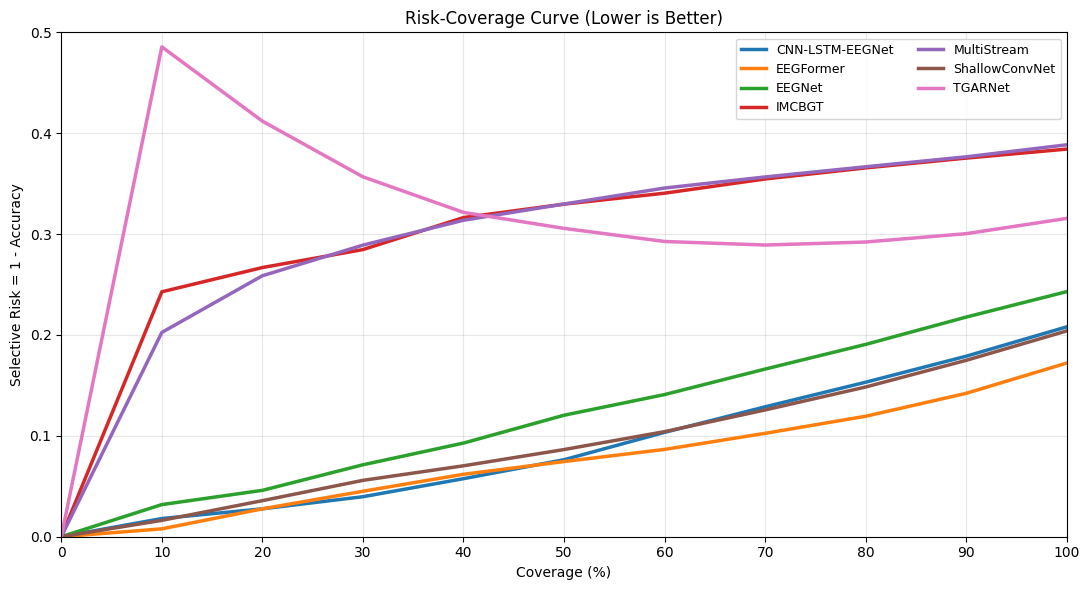

In [ ]:
# Confidence-based selective robustness at trial level (risk-coverage only)
coverage_grid_pct = np.arange(0, 101, 10)
coverage_grid = coverage_grid_pct / 100.0
bootstrap_repeats = 500
bootstrap_seed = 20260524

required_sel_cols = {'true_label', 'prob_adhd'}
for model_name, df in frames.items():
    missing = required_sel_cols - set(df.columns)
    if missing:
        raise ValueError(f"{model_name} missing required columns for selective robustness: {sorted(missing)}")

def selective_curve_from_probs(y_true, y_prob, coverage_values):
    y_pred = (y_prob >= 0.5).astype(int)

    # Standard confidence for binary classification
    conf = np.maximum(y_prob, 1.0 - y_prob)

    # Keep most confident trials first; stable keeps tie order deterministic
    order = np.argsort(-conf, kind='stable')
    y_true_s = y_true[order]
    y_pred_s = y_pred[order]
    correct_s = (y_true_s == y_pred_s).astype(int)
    cum_correct = np.cumsum(correct_s)

    rows = []
    n = len(y_true_s)
    for cov in coverage_values:
        k = int(np.clip(round(cov * n), 1, n))
        acc = float(cum_correct[k - 1] / k)
        risk = 1.0 - acc
        rows.append({'coverage': float(cov), 'accuracy': acc, 'risk': risk})
    return pd.DataFrame(rows)

sel_rows = []
aurc_rows = []
for model_name, df in frames.items():
    y_true = df['true_label'].astype(int).to_numpy()
    y_prob = df['prob_adhd'].astype(float).to_numpy()

    curve = selective_curve_from_probs(y_true, y_prob, coverage_grid)
    curve['model'] = model_name
    sel_rows.append(curve)

    aurc = float(np.trapezoid(curve['risk'].to_numpy(), curve['coverage'].to_numpy()))
    aurc_rows.append({'model': model_name, 'AURC': aurc})

selective_df = pd.concat(sel_rows, ignore_index=True)
aurc_df = pd.DataFrame(aurc_rows)

# Bootstrap CI for AURC
rng = np.random.default_rng(bootstrap_seed)
bootstrap_records = []
for model_name, df in frames.items():
    y_true = df['true_label'].astype(int).to_numpy()
    y_prob = df['prob_adhd'].astype(float).to_numpy()
    n = len(y_true)

    model_aurcs = []
    for _ in range(bootstrap_repeats):
        idx = rng.integers(0, n, size=n)
        curve_b = selective_curve_from_probs(y_true[idx], y_prob[idx], coverage_grid)
        aurc_b = float(np.trapezoid(curve_b['risk'].to_numpy(), curve_b['coverage'].to_numpy()))
        model_aurcs.append(aurc_b)

    bootstrap_records.append({
        'model': model_name,
        'AURC_boot_mean': float(np.mean(model_aurcs)),
        'AURC_ci95_low': float(np.quantile(model_aurcs, 0.025)),
        'AURC_ci95_high': float(np.quantile(model_aurcs, 0.975)),
    })

aurc_boot_df = pd.DataFrame(bootstrap_records)
aurc_summary = aurc_df.merge(aurc_boot_df, on='model', how='left').sort_values('AURC', ascending=True)

# Save CSV outputs for PGFPlots
out_dir = Path('../results/evaluation/pgfplots_data')
out_dir.mkdir(parents=True, exist_ok=True)

risk_curve_csv = out_dir / 'risk_coverage_curve.csv'
aurc_summary_csv = out_dir / 'risk_coverage_aurc_summary.csv'

risk_curve_export = selective_df.copy()
risk_curve_export['coverage_pct'] = (risk_curve_export['coverage'] * 100.0).round(0).astype(int)
risk_curve_export = risk_curve_export[['model', 'coverage', 'coverage_pct', 'accuracy', 'risk']]
risk_curve_export.to_csv(risk_curve_csv, index=False)
aurc_summary.to_csv(aurc_summary_csv, index=False)

print('AURC summary (lower is better):')
display(
    aurc_summary.style.format({
        'AURC': '{:.4f}',
        'AURC_boot_mean': '{:.4f}',
        'AURC_ci95_low': '{:.4f}',
        'AURC_ci95_high': '{:.4f}',
    })
)

print(f'Saved: {risk_curve_csv}')
print(f'Saved: {aurc_summary_csv}')

# Plot: risk-coverage curve (lower is better)
plt.figure(figsize=(11, 6))
for model_name, g in selective_df.groupby('model', sort=True):
    g = g.sort_values('coverage')
    plt.plot(g['coverage'] * 100.0, g['risk'], linewidth=2.5, label=model_name)

plt.title('Risk-Coverage Curve (Lower is Better)')
plt.xlabel('Coverage (%)')
plt.ylabel('Selective Risk = 1 - Accuracy')
plt.xlim(0, 100)
plt.xticks(coverage_grid_pct)
plt.ylim(0.0, 0.5)
plt.grid(alpha=0.3)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()